# IPN Cross-Correlation and Localization

This notebook contains an example of a cross-correlation time-delay calculation using three simulated GRB lightcurves, each "observed" by a different spacecraft. Using the Gamma-ray Data Tools (GDT), we will load in the lightcurves, fit the background, define the spacecraft positions, perform the cross-correlation, and use the resulting time offsets to produce a 3-detector IPN localization.

To get started, run the notebook cell below to load and display the data.

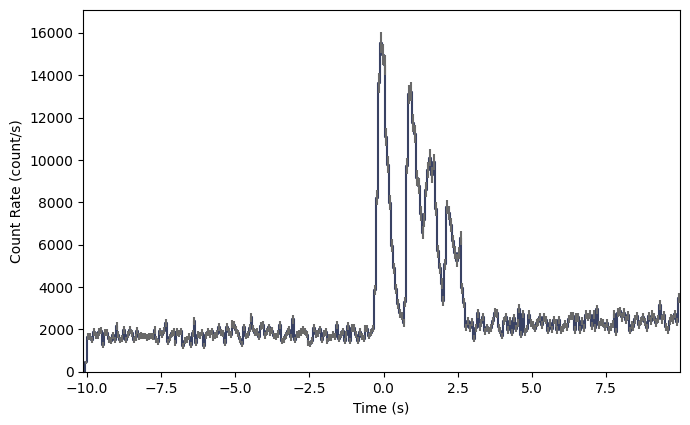

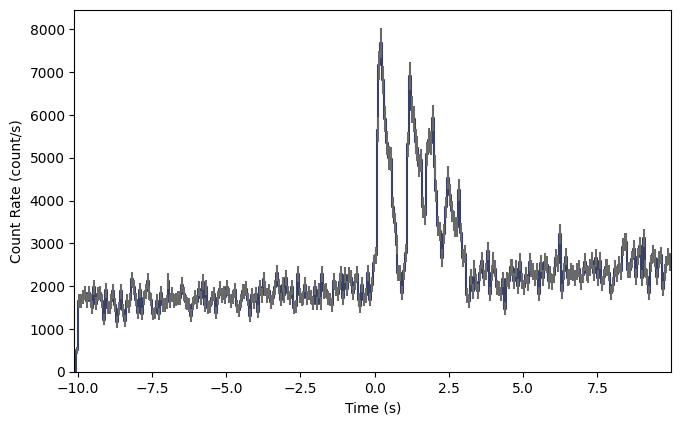

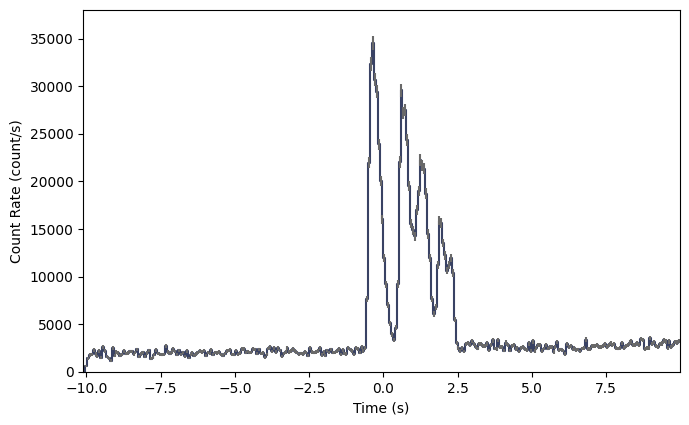

In [1]:
import matplotlib.pyplot as plt 
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from gdt.core.data_primitives import TimeEnergyBins
from gdt.core.plot.lightcurve import Lightcurve
from gdt.missions.fermi.gbm.phaii import Ctime


def ascii_to_phaii(file):
    """Function to convert the ASCII files to PHAII objects """
    tstart = []
    tstop = []
    counts = []

    # format the times and counts from the ASCII file
    with open(file, 'r') as f:
        txt = list(f)
        for line in txt:
            t0, t1, c = line.split()
            tstart.append(float(t0))
            tstop.append(float(t1))
            counts.append(float(c.strip()))
    tstart = np.array(tstart)
    tstop = np.array(tstop)
    counts = np.array(counts)
    
    # create the PHAII file
    counts = np.tile(counts, (2,1)).T
    bins = TimeEnergyBins(counts, tstart, tstop, (tstop-tstart), 
                          np.array([5.0, 50.0]), np.array([50.0, 300.0]))
    phaii = Ctime.from_data(bins, detector='n0')
    return phaii

# load in the data
phaii1 = ascii_to_phaii('data/LC_cat_v06_Npls6_catnum7_binned.txt')
phaii2 = ascii_to_phaii('data/LC_cat_v06_Npls6_catnum8_binned.txt')
phaii3 = ascii_to_phaii('data/LC_cat_v06_Npls6_catnum9_binned.txt')
phaiis = [phaii1, phaii2, phaii3]

# plot the data
lcplots = [Lightcurve(p.to_lightcurve()) for p in phaiis]
plt.show()

## Fit the background

The time delay calculate uses background-subtracted lightcurves, so first, we will fit the background in each "detector." 

Using the plots above as a guide, define the time intervals before and after the burst emission and choose the energy range over which to extract the lightcurve counts. Select time intervals near to but excluding the burst. Too long an interval results in the fitter wasting its degrees of freedom accommodating irrelevant wiggles; too short an interval results in significant statistical errors in the background estimation. 

TIP: If you encounter a `LinAlgError: Singular matrix` error when fitting the background, try selecting larger background regions.

In [2]:
# define background intervals and polynomial order
background_intervals = [(-9.0, -2.0), (5.0, 9.0)]
porder = 1

# define the energy range
energy_range = (50.0, 300.0)

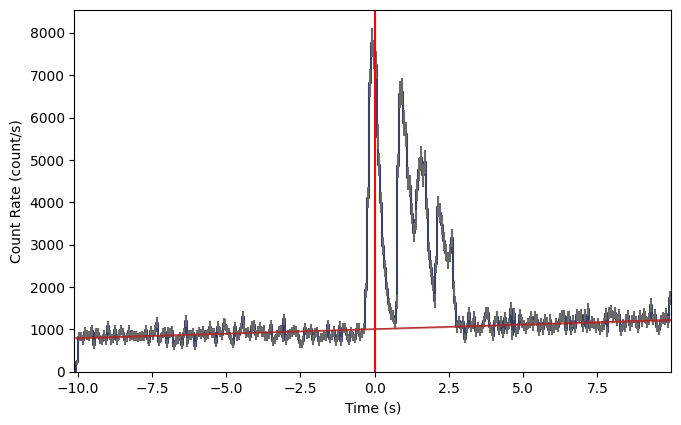

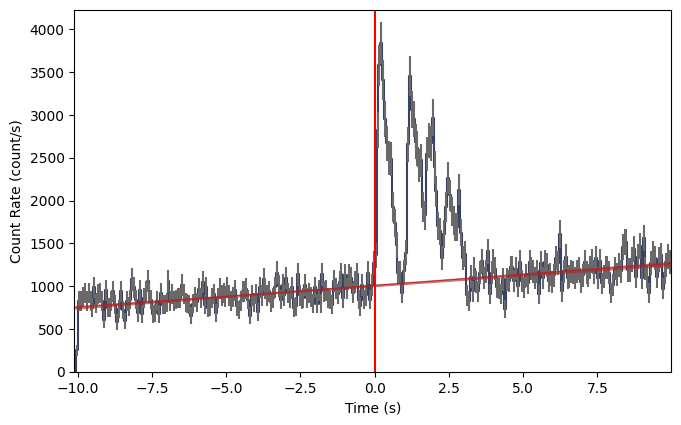

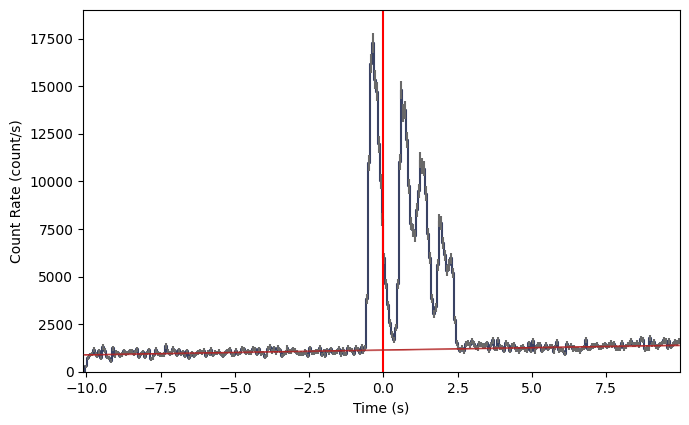

In [3]:
from gdt.core.background.fitter import BackgroundFitter
from gdt.core.background.binned import Polynomial

# initialize the background fitter with the data and background selections
bkgd_fitter1 = BackgroundFitter.from_phaii(phaii1, Polynomial, background_intervals)
bkgd_fitter1.fit(order=porder)
bkgd_model1 = bkgd_fitter1.interpolate_bins(phaii1.data.tstart, phaii1.data.tstop)

# fit the background of the second lightcurve
bkgd_fitter2 = BackgroundFitter.from_phaii(phaii2, Polynomial, background_intervals)
bkgd_fitter2.fit(order=porder)
bkgd_model2 = bkgd_fitter2.interpolate_bins(phaii2.data.tstart, phaii2.data.tstop)

# fit the background of the third lightcurve
bkgd_fitter3 = BackgroundFitter.from_phaii(phaii3, Polynomial, background_intervals)
bkgd_fitter3.fit(order=porder)
bkgd_model3 = bkgd_fitter3.interpolate_bins(phaii3.data.tstart, phaii3.data.tstop)

# plot the lightcurves
bkgd_fitters = [bkgd_fitter1, bkgd_fitter2, bkgd_fitter3]
bkgd_models = [bkgd_model1, bkgd_model2, bkgd_model3]

lcplots = [Lightcurve(data=phaii.to_lightcurve(energy_range=energy_range), 
                     background=bkgd_model.integrate_energy(*energy_range))
                     for phaii, bkgd_model in zip(phaiis, bkgd_models)]
for lcplot in lcplots:
    lcplot.ax.axvline(x=0, color='red')
    

## Create Observations
Next, we will save the lightcurve and background fit together as an `Observation`. We can also check the background fit by examining the background-subtracted lightcurves. If the background level is not close to zero through the data, then re-try the background fit with different time intervals or a different polynomial order.

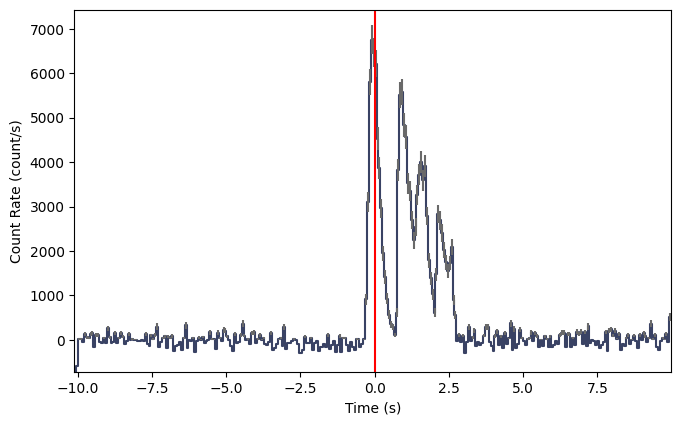

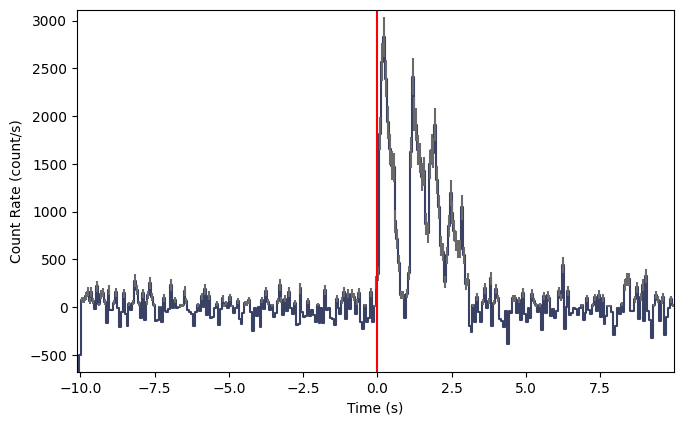

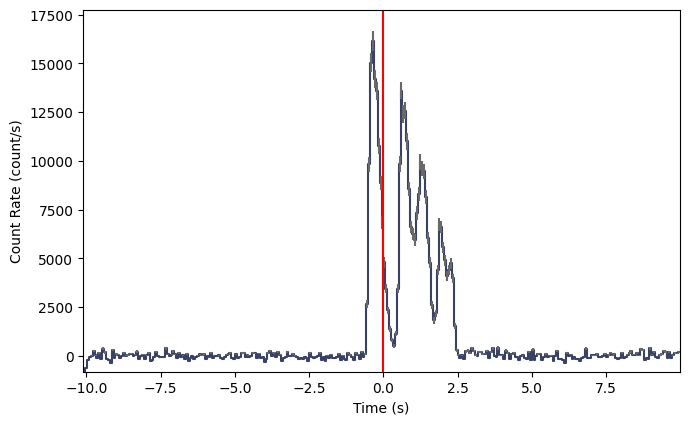

In [4]:
from gdt.ipn.instrument import Observation

# store the lightcurves and background as observations
observations = [Observation(phaii.to_lightcurve(energy_range=energy_range),
                            background=bkgd_model.integrate_energy(*energy_range))
                            for phaii, bkgd_model in zip(phaiis, bkgd_models)]

# plot the background-subtracted lightcurves
lcplots = [Lightcurve(data=observation.background_subtract()) for observation in observations]
for lcplot in lcplots:
    lcplot.ax.axvline(x=0, color='red')

## Set the Spacecraft Positions
Next, we will define the spacecraft positions, which given the time offset obtained from the cross-correlation analysis, are used to determine the GRB localization. 

In this example, we set both `spacecraft1` and `spacecraft3` in Low Earth Orbit (LEO) while `spacecraft2` is near the Moon.

In [5]:
from gdt.ipn.instrument import SpacecraftPosition

# define the spacraft positions used distance from the Earth in km
# the error on the distance is set to 0.0
scpos1 = SpacecraftPosition.from_distance(500.0, 0.0)
scpos2 = SpacecraftPosition.from_distance(2e5, 0.0)

# set the spacecraft vector in geocentric coordinates (km)
# positional errors are set to 0.0
scpos3 = SpacecraftPosition.from_vectors([350.0, -200.0, 350.0], [0.0, 0.0, 0.0])


Now we assign each spacecraft to a lightcurve: 

In [6]:
from gdt.ipn.instrument import Spacecraft

# initialize the Spacecraft objects
spacecraft1 = Spacecraft(scpos1)
spacecraft2 = Spacecraft(scpos2)
spacecraft3 = Spacecraft(scpos3)
spacecraft = [spacecraft1, spacecraft2, spacecraft3]

# assign the spacecraft with observation
_ = [spcft.set_observation(observation) for spcft, observation in zip(spacecraft,observations)]

## Find the time delays
Finally, we can calculate the time delays between the pairs of lightcurves. This is done by time-shifting one lightcurve relative to another and, for each shift, calculating both a Chi-squared-like statistic as well as a cross-correlation function (CCF). The time delay at which the Chi-squared is minimized and the CCF is maximized is reported, along with 3 sigma uncertainties.

The Chi-squared-like statistic is described in Pal'shin et al., 2013, and requires a source selection for each lightcurve. Using the background-subtracted plots above as guides, input the source selections in the cell below. They must be approximately the same length in duration.


In [7]:
src1 = (-1., 3.)
src2 = (0., 4.)
src3 = (-1., 3.)

Now, let's calculate the time delays!

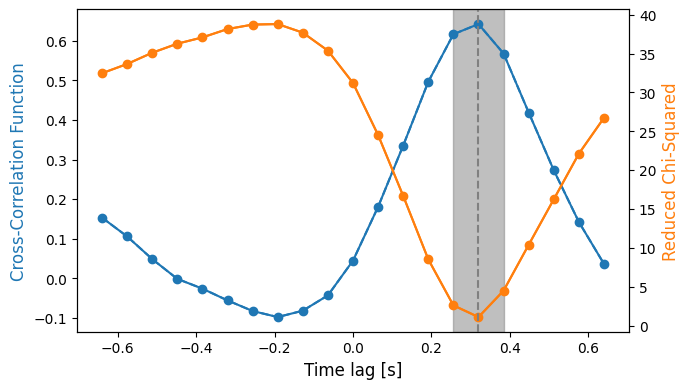

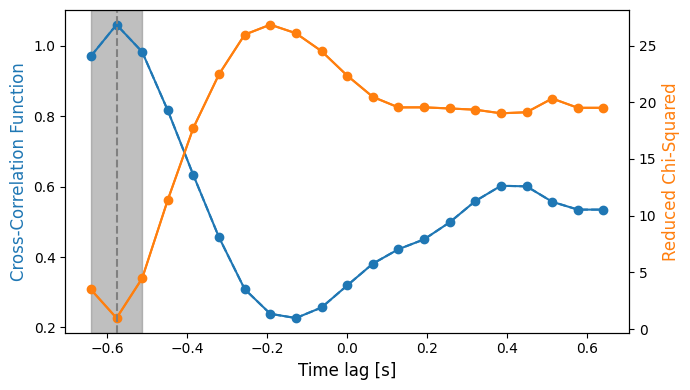

Time offset: 0.320 (+0.064, -0.064)
Time offset: -0.576 (+0.064, -0.064)


In [8]:
from gdt.ipn.algorithms.ccf import Ipn

# initialize the IPN with the spacecraft
ipn1 = Ipn.from_list([spacecraft1, spacecraft2])
ipn2 = Ipn.from_list([spacecraft2, spacecraft3])

# perform the time shifts
ipn1.localize(src1, src2)
ipn2.localize(src2, src3)

# plot the fit of the CCF and chisq for each time shift
ipn1.plot_fit()
ipn2.plot_fit()

# the time offset and error
print('Time offset: {0:.3f} (+{1:.3f}, -{2:.3f})'.format(ipn1.time_offset.dt, ipn1.time_offset.err[1], ipn1.time_offset.err[0]))
print('Time offset: {0:.3f} (+{1:.3f}, -{2:.3f})'.format(ipn2.time_offset.dt, ipn2.time_offset.err[1], ipn2.time_offset.err[0]))

The plots look good! In both examples, the Chi-squared-like statistic and CCF agree and the uncertainties appear reasonable. With our time delays in hand, we can now calculate the source localization. 

## Localization
For each pair of observations, we can use the spacecraft positions and the difference in time-of-arrival to localize the source to an annulus on the sky. 

Here, the annulus from the first pair of spacecraft is shown as two black contours centered around RA=180, Dec=0. The second annulus is plotted with the localization probability density centered around RA=275, Dec=0.

NOTE: you can set the nside of the HealPix skymap. The smaller the annulus width, the higher the nside required to resolve it, and the longer the cell will take to run.

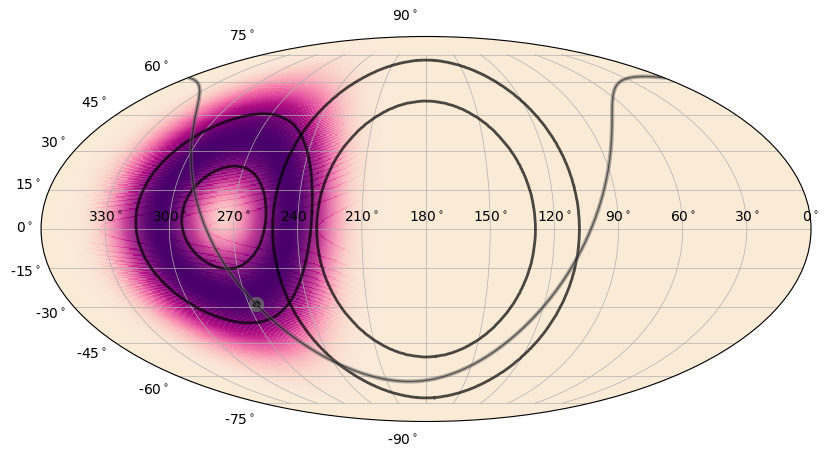

In [10]:
from gdt.core.plot.sky import EquatorialPlot
from gdt.core.healpix import HealPixLocalization

# set the map resolution
nside = 256

# generate the healpix objects
hpx1 = ipn1.get_healpix(nside=nside)
hpx2 = ipn2.get_healpix(nside=nside)

# plot the first annulus from ipn1
skyplot = EquatorialPlot()
skyplot.add_localization(hpx1, clevels=[0.90], gradient=True, sun=False, earth=False, detectors=[])

# add the second annulus from ipn2 
skyplot.add_localization(hpx2, clevels=[0.68], gradient=True, sun=False, earth=False, detectors=[])
plt.show()
plt.close()

## Joint Localization
We can also combine the two annuli to produce one joint localization.

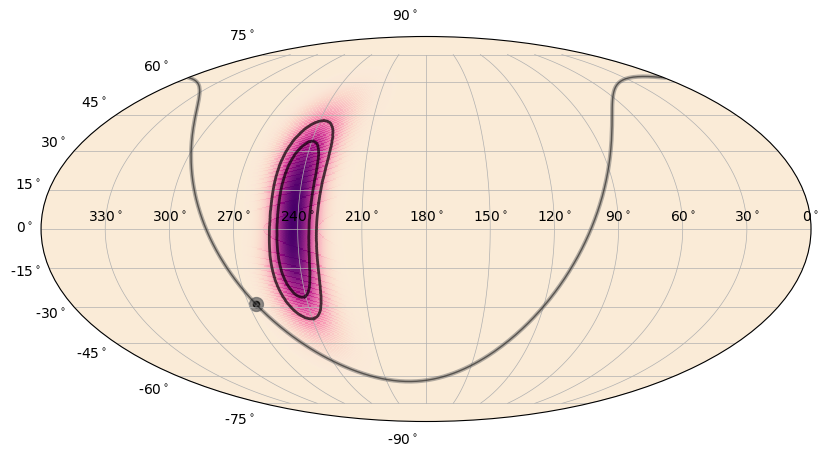

In [ ]:
import healpy as hp

# Create the joint probability skymaps
nside = hpx1.nside  # Ensure both maps are the same resolution before multiplication
prob1 = hpx1.prob if hpx1.nside == nside else hp.ud_grade(hpx1.prob, nside_out=nside)
prob2 = hpx2.prob if hpx2.nside == nside else hp.ud_grade(hpx2.prob, nside_out=nside)

joint_prob = prob1 * prob2
joint_prob /= joint_prob.sum()  # normalize

# Make a new HealPixLocalization object
joint_hpx = HealPixLocalization.from_data(joint_prob)

#skypatch plot 
skyplot = EquatorialPlot()
skyplot.add_localization(joint_hpx, clevels=[0.68, 0.90], sun=False, earth=False, detectors=[])
plt.show()
plt.close()